# 01 · Inventory — what the National Highways data contains

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

Lengths are geodesic. Divided highways are drawn as two one-way ways in OSM, so each way carries a weight (0.5 when an opposite-direction partner runs within 30 m) and `eff_km` counts each road once.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
seg = nh.segments()
km = seg.groupby(["kind", "status"])[["length_km", "eff_km"]].sum().round(0)
km

length_km     eff_km
kind               status                                  
expressway_segment operational         22,250.00  12,726.00
                   proposed             2,234.00   2,234.00
                   under_construction   6,661.00   4,539.00
nh_segment         operational        177,112.00 133,596.00
                   proposed               516.00     516.00
                   under_construction   5,506.00   4,203.00

## Coverage against the official MoRTH length
`osm_nh_km` counts operational ways with an NH/NE ref, tagged `trunk` (OSM India convention) or belonging to an NH route relation, once per road. `nhai_nh_km` is NHAI's own completed NH layer.

In [3]:
cov = pd.read_csv(A / "coverage_by_state.csv")
i = cov[cov.state == "India"].iloc[0]
print(f"Official: {i.official_km:,.0f} km | OSM: {i.osm_nh_km:,.0f} km ({i.osm_ratio:.1%}) | NHAI completed: {i.nhai_nh_km:,.0f} km ({i.nhai_ratio:.1%})")
cov[cov.state != "India"].set_index("state")[["official_km", "osm_nh_km", "nhai_nh_km", "osm_ratio", "nhai_ratio"]]

Official: 146,194 km | OSM: 142,905 km (97.8%) | NHAI completed: 136,758 km (93.5%)


,official_km,osm_nh_km,nhai_nh_km,osm_ratio,nhai_ratio
state,,,,,
Maharashtra,"18,462.00","18,332.50","18,350.86",0.99,0.99
Uttar Pradesh,"12,123.00","13,314.17","12,131.81",1.10,1.00
Rajasthan,"10,733.00","11,580.51","9,723.33",1.08,0.91
Madhya Pradesh,"9,160.00","9,819.24","9,019.42",1.07,0.98
Andhra Pradesh,"8,683.00","7,912.65","7,841.30",0.91,0.90
Karnataka,"8,191.00","7,982.51","7,646.06",0.97,0.93
Gujarat,"8,111.00","7,780.12","7,000.32",0.96,0.86
Tamil Nadu,"7,000.00","6,986.68","7,128.23",1.00,1.02
Bihar,"6,132.00","5,853.06","6,318.58",0.95,1.03


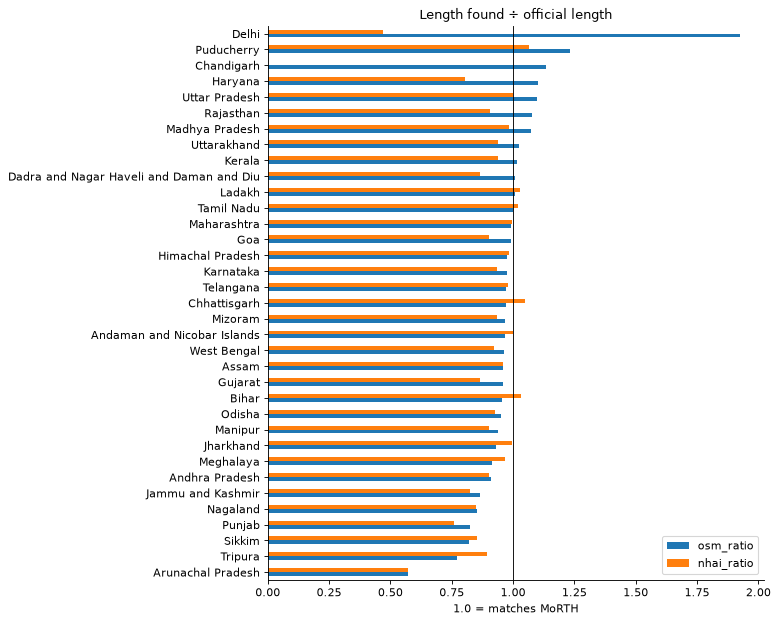

In [4]:
c = cov[(cov.state != "India") & (cov.official_km > 0)].sort_values("osm_ratio")
ax = c.plot.barh(x="state", y=["osm_ratio", "nhai_ratio"], figsize=(8, 9), title="Length found ÷ official length")
ax.axvline(1, color="k", lw=0.8)
ax.set_xlabel("1.0 = matches MoRTH")
ax.set_ylabel("");

## Attribute completeness (share of operational NH length)

In [5]:
comp = pd.read_csv(A / "completeness_by_state.csv", index_col=0)
display(comp.loc[["India"]])
comp.drop("India").sort_values("has_lanes").head(10)

,has_ref,has_lanes,has_surface,has_maxspeed,has_name
state,,,,,
India,0.96,0.49,0.41,0.16,0.28


,has_ref,has_lanes,has_surface,has_maxspeed,has_name
state,,,,,
Manipur,1.00,0.01,0.01,0.01,0.14
Mizoram,1.00,0.02,0.08,0.01,0.01
Sikkim,1.00,0.03,0.21,0.01,0.39
Arunachal Pradesh,1.00,0.07,0.07,0.02,0.09
Nagaland,1.00,0.10,0.12,0.03,0.20
Ladakh,1.00,0.13,0.88,0.11,0.35
Tripura,0.98,0.14,0.21,0.00,0.07
Dadra and Nagar Haveli and Daman and Diu,1.00,0.14,0.01,0.07,0.17
Andaman and Nicobar Islands,1.00,0.15,0.15,0.16,0.36


## Lane mix (km)
OSM tags `lanes` per carriageway, so one side of a paired dual carriageway counts double (two 2-lane sides = a 4-lane road). NHAI bands come from its own completed-NH layer.

In [6]:
lm = pd.read_csv(A / "lane_mix_by_state.csv", header=[0, 1], index_col=0)
lm.loc[["India"]]

osm                                          nhai            \
band          2         4       6+     <2   unknown         2         4   
state                                                                     
India 35,312.00 28,065.00 7,430.00 357.00 75,122.00 92,773.00 31,729.00   

                         
band        6+       <2  
state                    
India 5,097.00 7,158.00